In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import pandas as pd
import numpy as np

df = pd.read_csv('epl_final.csv')  # adjust path if using Google Drive
df['MatchDate'] = pd.to_datetime(df['MatchDate'])
df = df.sort_values('MatchDate').reset_index(drop=True)
df['MatchID'] = df.index
df.head()

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,MatchID
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,4,6,6,13,12,1,2,0,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,5,7,7,19,14,1,2,0,0,1
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,9,8,4,15,21,5,3,1,0,2
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,6,5,8,11,13,1,1,0,0,3
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,6,6,4,21,20,1,3,0,0,4


In [32]:
def result_points(row, is_home):
    if row['FullTimeResult'] == 'D':
        return 1
    if is_home and row['FullTimeResult'] == 'H':
        return 3
    if not is_home and row['FullTimeResult'] == 'A':
        return 3
    return 0

home_records = df[['MatchID','MatchDate','HomeTeam','FullTimeHomeGoals','FullTimeAwayGoals']].copy()
home_records['Team'] = home_records['HomeTeam']
home_records['GoalsFor'] = home_records['FullTimeHomeGoals']
home_records['GoalsAgainst'] = home_records['FullTimeAwayGoals']
home_records['Points'] = df.apply(lambda r: result_points(r, True), axis=1)

away_records = df[['MatchID','MatchDate','AwayTeam','FullTimeHomeGoals','FullTimeAwayGoals']].copy()
away_records['Team'] = away_records['AwayTeam']
away_records['GoalsFor'] = away_records['FullTimeAwayGoals']
away_records['GoalsAgainst'] = away_records['FullTimeHomeGoals']
away_records['Points'] = df.apply(lambda r: result_points(r, False), axis=1)

team_long = pd.concat([
    home_records[['MatchID','MatchDate','Team','Points','GoalsFor','GoalsAgainst']],
    away_records[['MatchID','MatchDate','Team','Points','GoalsFor','GoalsAgainst']]
]).sort_values(['Team','MatchDate'])

for col, new_col in [('Points','Form5'), ('GoalsFor','GoalsForAvg5'), ('GoalsAgainst','GoalsAgainstAvg5')]:
    team_long[new_col] = (
        team_long.groupby('Team')[col]
        .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    )

team_long.head()

,MatchID,MatchDate,Team,Points,GoalsFor,GoalsAgainst,Form5,GoalsForAvg5,GoalsAgainstAvg5
7,7,2000-08-19,Arsenal,0,0,1,NaN,NaN,NaN
10,10,2000-08-21,Arsenal,3,2,0,0.00,0.000000,1.000000
20,20,2000-08-26,Arsenal,3,5,3,1.50,1.000000,0.500000
37,37,2000-09-06,Arsenal,1,2,2,2.00,2.333333,1.333333
39,39,2000-09-09,Arsenal,1,1,1,1.75,2.250000,1.500000


In [33]:
home_feat = team_long[['MatchID','Team','Form5','GoalsForAvg5','GoalsAgainstAvg5']].rename(
    columns={'Team':'HomeTeam','Form5':'HomeForm5','GoalsForAvg5':'HomeGoalsForAvg5','GoalsAgainstAvg5':'HomeGoalsAgainstAvg5'})
away_feat = team_long[['MatchID','Team','Form5','GoalsForAvg5','GoalsAgainstAvg5']].rename(
    columns={'Team':'AwayTeam','Form5':'AwayForm5','GoalsForAvg5':'AwayGoalsForAvg5','GoalsAgainstAvg5':'AwayGoalsAgainstAvg5'})

df = df.merge(home_feat, on=['MatchID','HomeTeam'], how='left')
df = df.merge(away_feat, on=['MatchID','AwayTeam'], how='left')
df.head()

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,AwayYellowCards,HomeRedCards,AwayRedCards,MatchID,HomeForm5,HomeGoalsForAvg5,HomeGoalsAgainstAvg5,AwayForm5,AwayGoalsForAvg5,AwayGoalsAgainstAvg5
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,2,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,2,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,1,0,2,NaN,NaN,NaN,NaN,NaN,NaN
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,1,0,0,3,NaN,NaN,NaN,NaN,NaN,NaN
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,3,0,0,4,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
h2h_points = []
history = {}
for idx, row in df.iterrows():
    key = tuple(sorted([row['HomeTeam'], row['AwayTeam']]))
    past = history.get(key, [])
    if past:
        home_wins_as_home = sum(1 for p in past if p['winner'] == row['HomeTeam'])
        h2h_rate = home_wins_as_home / len(past)
    else:
        h2h_rate = np.nan
    h2h_points.append(h2h_rate)
    winner = row['HomeTeam'] if row['FullTimeResult']=='H' else (row['AwayTeam'] if row['FullTimeResult']=='A' else 'Draw')
    history.setdefault(key, []).append({'winner': winner})

df['H2H_HomeWinRate'] = h2h_points

model_df = df.dropna(subset=['HomeForm5','AwayForm5','H2H_HomeWinRate']).reset_index(drop=True)
print(f"Rows before: {len(df)}, after dropping early no-history matches: {len(model_df)}")

Rows before: 9380, after dropping early no-history matches: 8586


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

features = ['HomeForm5','AwayForm5','HomeGoalsForAvg5','HomeGoalsAgainstAvg5',
            'AwayGoalsForAvg5','AwayGoalsAgainstAvg5','H2H_HomeWinRate']
X = model_df[features]
y = model_df['FullTimeResult']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

baseline_acc = (y_test == 'H').mean()
print(f'Baseline (always predict Home Win): {baseline_acc:.3f}')

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
print(f'Logistic Regression accuracy: {accuracy_score(y_test, log_reg.predict(X_test)):.3f}')

rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_test)
print(f'Random Forest accuracy: {accuracy_score(y_test, preds_rf):.3f}')
print()
print(classification_report(y_test, preds_rf))

Baseline (always predict Home Win): 0.435
Logistic Regression accuracy: 0.510
Random Forest accuracy: 0.498

              precision    recall  f1-score   support

           A       0.50      0.35      0.42       574
           D       0.00      0.00      0.00       397
           H       0.50      0.87      0.63       747

    accuracy                           0.50      1718
   macro avg       0.33      0.41      0.35      1718
weighted avg       0.38      0.50      0.41      1718



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


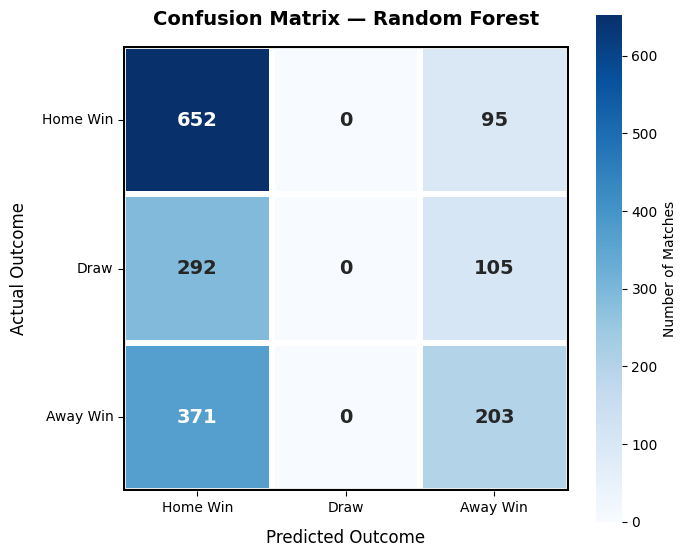

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, preds_rf, labels=['H','D','A'])

plt.figure(figsize=(7,6))
ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Home Win','Draw','Away Win'],
    yticklabels=['Home Win','Draw','Away Win'],
    linewidths=3,          # thickness of the border between cells
    linecolor='white',     # border color between cells
    cbar_kws={'label': 'Number of Matches'},
    annot_kws={'size': 14, 'weight': 'bold'},
    square=True
)

# Thick border around the WHOLE grid too
ax.axhline(y=0, color='black', linewidth=3)
ax.axhline(y=3, color='black', linewidth=3)
ax.axvline(x=0, color='black', linewidth=3)
ax.axvline(x=3, color='black', linewidth=3)

plt.xlabel('Predicted Outcome', fontsize=12, labelpad=10)
plt.ylabel('Actual Outcome', fontsize=12, labelpad=10)
plt.title('Confusion Matrix — Random Forest', fontsize=14, weight='bold', pad=15)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

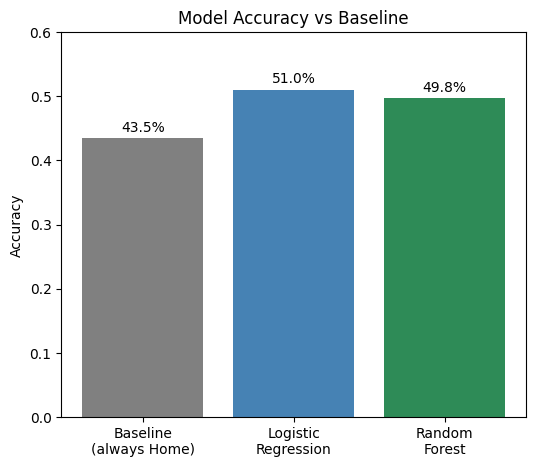

In [37]:
results = {
    'Baseline\n(always Home)': baseline_acc,
    'Logistic\nRegression': accuracy_score(y_test, log_reg.predict(X_test)),
    'Random\nForest': accuracy_score(y_test, preds_rf)
}

plt.figure(figsize=(6,5))
bars = plt.bar(results.keys(), results.values(), color=['gray','steelblue','seagreen'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy vs Baseline')
plt.ylim(0, 0.6)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.1%}', ha='center')
plt.show()